# Libraries import

In [183]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import(accuracy_score, classification_report, f1_score,precision_score, recall_score ,ConfusionMatrixDisplay)

from sklearn.naive_bayes  import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PassiveAggressiveClassifier


print("Library imported successfully!")

Library imported successfully!


In [184]:
df = pd.read_csv('fake_job_postings.csv')

In [185]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [186]:
df.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


In [187]:
df.shape

(17880, 18)

In [188]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [190]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [191]:
text_columns = ['company_profile', 'description', 'requirements', 'benefits']

for col in text_columns:
    df[col] = df[col].fillna('')

In [192]:
cat_columns = ['location', 'department', 'salary_range', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for col2 in cat_columns:
    df[col2] = df[col2].fillna('missing')


In [193]:
df.duplicated().sum()

np.int64(0)

In [194]:
df.shape

(17880, 18)

# Target: 'fraudulent' (0 = real, 1 = fake)

In [195]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

# Visualization 

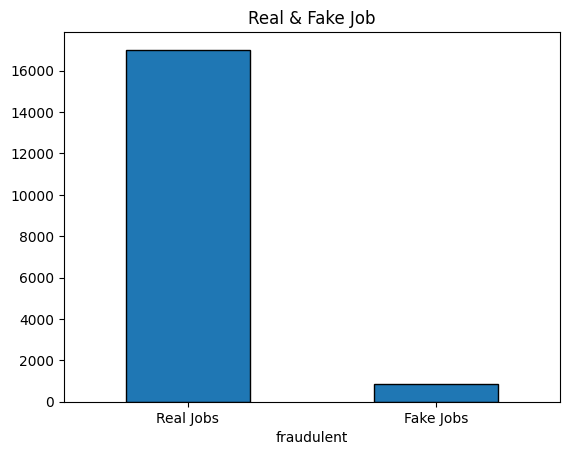

In [196]:
real_fake_graph = df['fraudulent'].value_counts()
real_fake_graph.plot(kind='bar',edgecolor='black')
plt.title('Real & Fake Job')
plt.xticks([0,1], ['Real Jobs', 'Fake Jobs'], rotation=0)
plt.show()

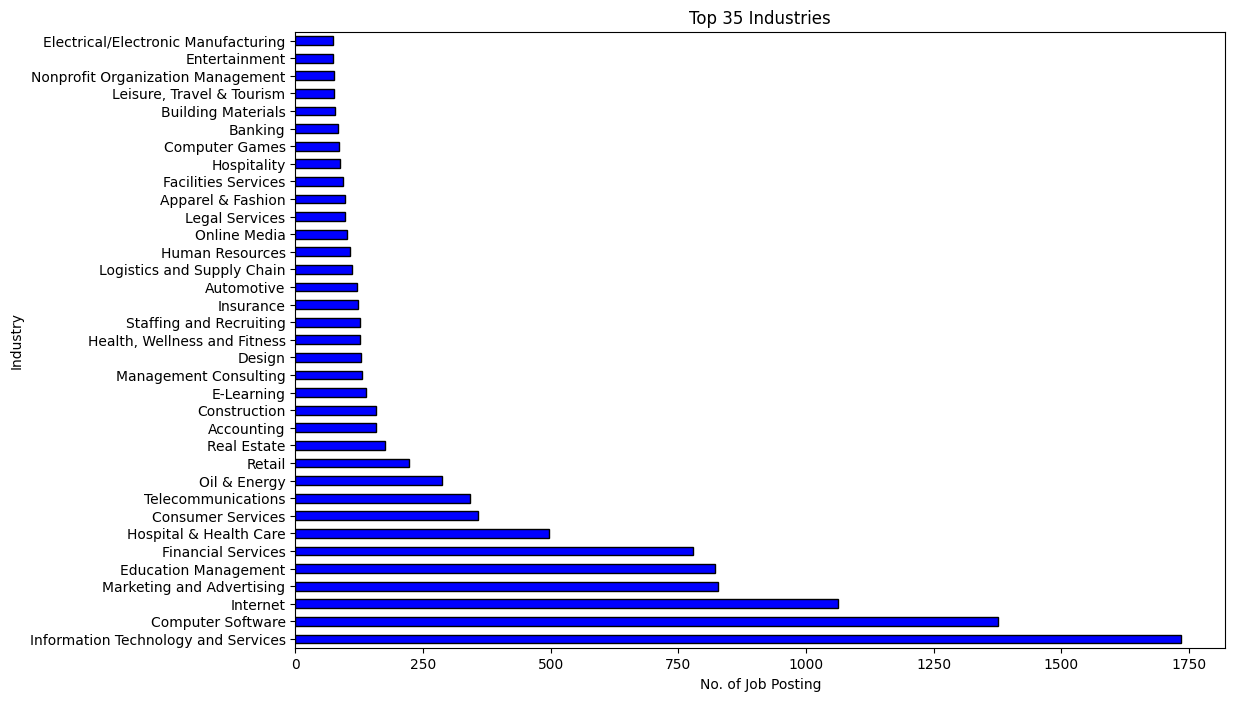

In [197]:
top_industries = (df[df['industry'] != 'missing']['industry'].value_counts().head(35))
plt.figure(figsize=(12,8))
top_industries.plot(kind='barh', color='blue', edgecolor='black')
plt.title('Top 35 Industries')
plt.xlabel("No. of Job Posting")
plt.ylabel('Industry')
plt.show()

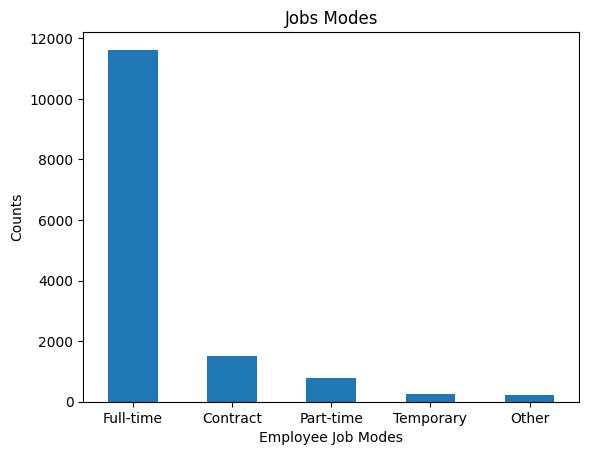

In [198]:
employee_work_mode = (df[df['employment_type'] != 'missing']['employment_type'].value_counts())
employee_work_mode.plot(kind='bar', rot=0)
plt.title('Jobs Modes')
plt.xlabel('Employee Job Modes')
plt.ylabel('Counts')
plt.show()

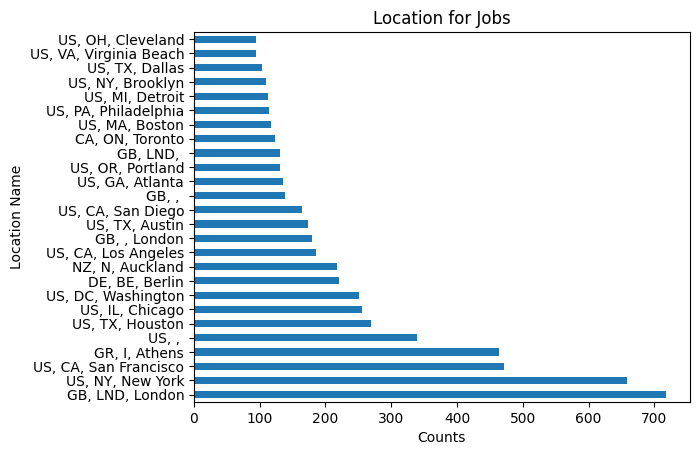

In [199]:
loc = (df[df['location'] != 'missing']['location'].value_counts().head(26))
loc.plot(kind='barh')
plt.title("Location for Jobs")
plt.xlabel("Counts")
plt.ylabel("Location Name")
plt.show()

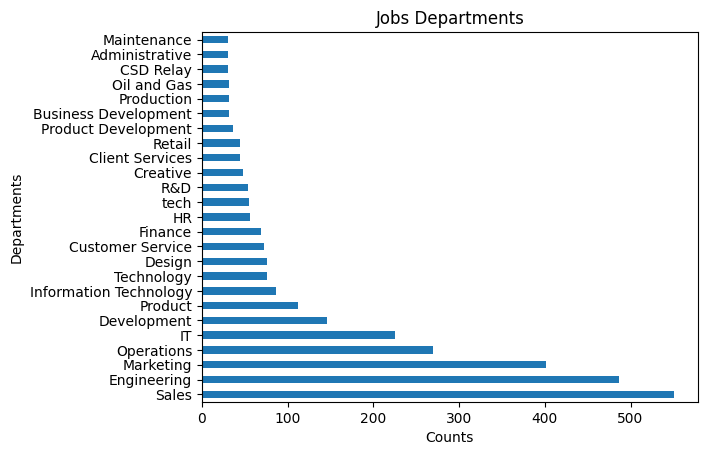

In [200]:
salary = (df[df['department'] != 'missing']['department'].value_counts().head(25))
salary.plot(kind='barh')
plt.title("Jobs Departments")
plt.xlabel("Counts")
plt.ylabel("Departments")
plt.show()

# Combine text columns

In [201]:
text_columns.insert(0, 'title')
print(text_columns)

['title', 'company_profile', 'description', 'requirements', 'benefits']


In [202]:
df['full_text'] = df[text_columns].agg(' '.join, axis=1)

In [203]:
X = df['full_text']
y = df['fraudulent']

# Train test split

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Converting text into numerical features using TF-IDF Vectorizer

In [205]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Model Implementation

# `Model 1 : LogisticRegression`

In [206]:
lrmodel = LogisticRegression()
lrmodel.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [207]:
y_pred = lrmodel.predict(X_test_tfidf)

In [208]:
print("Accuracy Score is ", accuracy_score(y_test, y_pred))
print("F1 Score is ", f1_score(y_test, y_pred))
print("Classification Report :\n")
print(classification_report(y_test, y_pred))

Accuracy Score is  0.9725950782997763
F1 Score is  0.6048387096774194
Classification Report :

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.43      0.60       173

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



# `Model 2 : Multinomial Naive Bayes`

In [209]:
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [210]:
y_pred_mnb = mnb.predict(X_test_tfidf)

In [211]:
print("Accuracy Score is ", accuracy_score(y_test, y_pred_mnb))
print("F1 Score is ", f1_score(y_test, y_pred_mnb))
print("Classification Report :\n")
print(classification_report(y_test, y_pred_mnb))

Accuracy Score is  0.9675615212527964
F1 Score is  0.4956521739130435
Classification Report :

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       1.00      0.33      0.50       173

    accuracy                           0.97      3576
   macro avg       0.98      0.66      0.74      3576
weighted avg       0.97      0.97      0.96      3576



# `Model 3 : Linear SVM`

In [212]:
l_SVM = LinearSVC()
l_SVM.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [213]:
y_pred_lsvm = l_SVM.predict(X_test_tfidf)

In [214]:
print("Accuracy Score is ", accuracy_score(y_test, y_pred_lsvm))
print("F1 Score is ", f1_score(y_test, y_pred_lsvm))
print("Classification Report :\n")
print(classification_report(y_test, y_pred_lsvm))

Accuracy Score is  0.985178970917226
F1 Score is  0.8250825082508251
Classification Report :

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.96      0.72      0.83       173

    accuracy                           0.99      3576
   macro avg       0.97      0.86      0.91      3576
weighted avg       0.98      0.99      0.98      3576



# `Model 4 : KNeighborsClassifier`

In [215]:
knn = KNeighborsClassifier()
knn.fit(X_train_tfidf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [216]:
y_pred_knn = knn.predict(X_test_tfidf)

In [217]:
print("Accuracy Score is ", accuracy_score(y_test, y_pred_knn))
print("F1 Score is ", f1_score(y_test, y_pred_knn))
print("Classification Report :\n")
print(classification_report(y_test, y_pred_knn))

Accuracy Score is  0.9793064876957495
F1 Score is  0.7628205128205128
Classification Report :

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.86      0.69      0.76       173

    accuracy                           0.98      3576
   macro avg       0.92      0.84      0.88      3576
weighted avg       0.98      0.98      0.98      3576



# `Model 5 : RandomForestClassifier`

In [218]:
rfc = RandomForestClassifier()
rfc.fit(X_train_tfidf, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [219]:
y_pred_rfc = rfc.predict(X_test_tfidf)

In [220]:
print("Accuracy Score is ", accuracy_score(y_test, y_pred_rfc))
print("F1 Score is ", f1_score(y_test, y_pred_rfc))
print("Classification Report :\n")
print(classification_report(y_test, y_pred_rfc))

Accuracy Score is  0.9804250559284117
F1 Score is  0.7463768115942029
Classification Report :

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.60      0.75       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



# `Model 6 : Passive Aggressive Classifier`

In [221]:
pac = PassiveAggressiveClassifier()
pac.fit(X_train_tfidf, y_train)

,C,1.0
,fit_intercept,True
,max_iter,1000
,tol,0.001
,early_stopping,False
,validation_fraction,0.1
,n_iter_no_change,5
,shuffle,True
,verbose,0
,loss,'hinge'
,n_jobs,None


In [222]:
y_pred_pac = pac.predict(X_test_tfidf)

In [223]:
print("Accuracy Score is ", accuracy_score(y_test, y_pred_pac))
print("F1 Score is ", f1_score(y_test, y_pred_pac))
print("Classification Report :\n")
print(classification_report(y_test, y_pred_pac))

Accuracy Score is  0.9829418344519015
F1 Score is  0.8157099697885196
Classification Report :

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.85      0.78      0.82       173

    accuracy                           0.98      3576
   macro avg       0.92      0.89      0.90      3576
weighted avg       0.98      0.98      0.98      3576



# Best Models

In [224]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Passive Aggressive Classifier": PassiveAggressiveClassifier()
}

result = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    
    y_pred_model = model.predict(X_test_tfidf)
    
    result.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'F1 Score': f1_score(y_test, y_pred_model)
    })
    
result_df = pd.DataFrame(result)

print(result_df)

                           Model  Accuracy  Precision    Recall  F1 Score
0            Logistic Regression  0.972595   1.000000  0.433526  0.604839
1                    Naive Bayes  0.967562   1.000000  0.329480  0.495652
2                     Linear SVC  0.985179   0.961538  0.722543  0.825083
3                  Random Forest  0.980145   1.000000  0.589595  0.741818
4                            KNN  0.979306   0.856115  0.687861  0.762821
5  Passive Aggressive Classifier  0.983501   0.860759  0.786127  0.821752


In [225]:
best_model = result_df.iloc[result_df['F1 Score'].idxmax()]

print("Best Model :", best_model["Model"])
print("Best F1 Score :", best_model["F1 Score"])

Best Model : Linear SVC
Best F1 Score : 0.8250825082508251


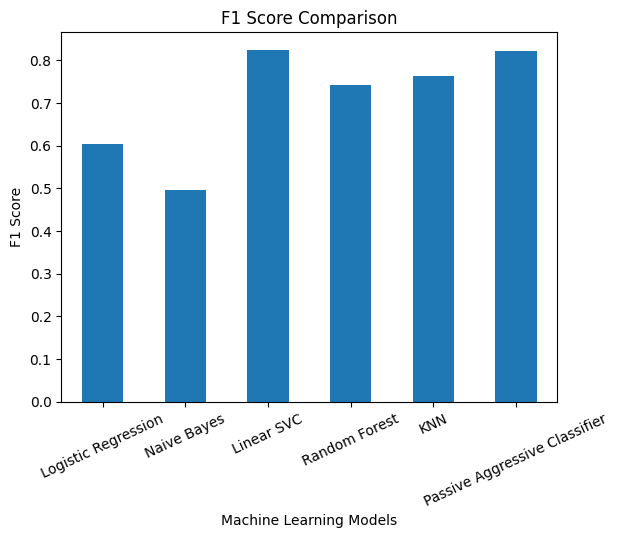

In [226]:
result_df.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    legend=False
)

plt.title("F1 Score Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=25)

plt.show()

# Confusion Matrix

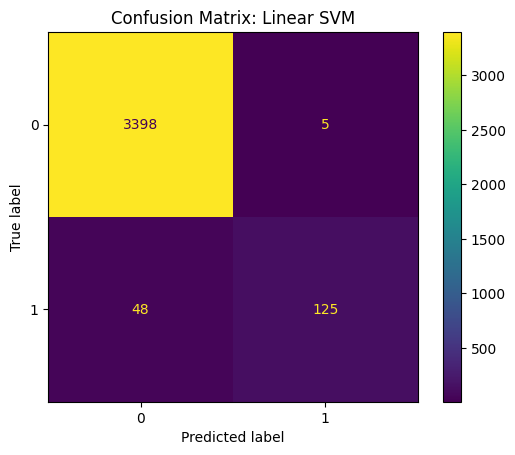

In [227]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lsvm)
plt.title('Confusion Matrix: Linear SVM')
plt.show()

# HyperParamter Tuning of Linear SVM Model

In [228]:
param_grid = {
    'C' : [0.01,0.1,1,10,100]
}

grid = GridSearchCV(estimator=LinearSVC(random_state=42), param_grid=param_grid, cv=5, scoring='f1')
grid.fit(X_train_tfidf, y_train)

,estimator,LinearSVC(random_state=42)
,param_grid,"{'C': [0.01, 0.1, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [229]:
print("Best Parameter : ", grid.best_estimator_)
print("Best F1 Score is ", grid.best_score_)

Best Parameter :  LinearSVC(C=1, random_state=42)
Best F1 Score is  0.7915498683664752


In [230]:
best_mod = grid.best_estimator_``
y_predict = best_mod.predict(X_test_tfidf)

SyntaxError: invalid syntax (2710963877.py, line 1)

In [ ]:
print("Accuracy Score is ", accuracy_score(y_test, y_predict))
print("F1 Score is ", f1_score(y_test, y_predict))
print("Classification Report :\n")
print(classification_report(y_test, y_predict))

Accuracy Score is  0.985178970917226
F1 Score is  0.8250825082508251
Classification Report :

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.96      0.72      0.83       173

    accuracy                           0.99      3576
   macro avg       0.97      0.86      0.91      3576
weighted avg       0.98      0.99      0.98      3576



In [ ]:
import pickle
pickle.dump(l_SVM, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

# User Prediction System

In [ ]:
def predict_job(text):
    text_tfidf = tfidf.transform([text])
    prediction = l_SVM.predict(text_tfidf)
    
    if prediction == 0:
        return "Legitimate Job"
    else:
        return "Fraudulent Job"

In [ ]:
sample_job = """Software Engineer

ABC Technologies Pvt. Ltd. is looking for a Software Engineer to join our development team.

Responsibilities:
- Develop and maintain web applications.
- Write clean and efficient Python code.
- Collaborate with cross-functional teams.
- Participate in code reviews.

Requirements:
- Bachelor's degree in Computer Science or related field.
- 1-3 years of experience in Python, SQL, and Django.
- Good problem-solving and communication skills.

Benefits:
- Health insurance
- Paid leave
- Flexible working hours
- Performance bonus

Location: Bangalore, India
Employment Type: Full-time
"""
print("Prediction is",predict_job(sample_job))

Prediction is Legitimate Job


In [ ]:
sample_job2 = """
URGENT HIRING!!!

Earn ₹2,00,000 every week from home.

No experience required.
No interview.
No qualifications needed.

Limited seats available.

Pay a refundable registration fee of ₹999 to reserve your position.

Work only 1 hour per day using your mobile phone.

Guaranteed income.

Contact immediately on WhatsApp to receive your appointment letter.

Join today and become financially free!
"""

print("Prediction is",predict_job(sample_job2))

Prediction is Fraudulent Job
